<!-- parity-note -->
## MATLAB Parity Note
- Source MATLAB helpfile: `DecodingExample.mlx`
- Fidelity status: `high_fidelity`
- Remaining justified differences: Workflow, model fitting, and decoded-stimulus figures now follow the MATLAB helpfile closely; exact traces still depend on stochastic simulation draws and Python plotting defaults.


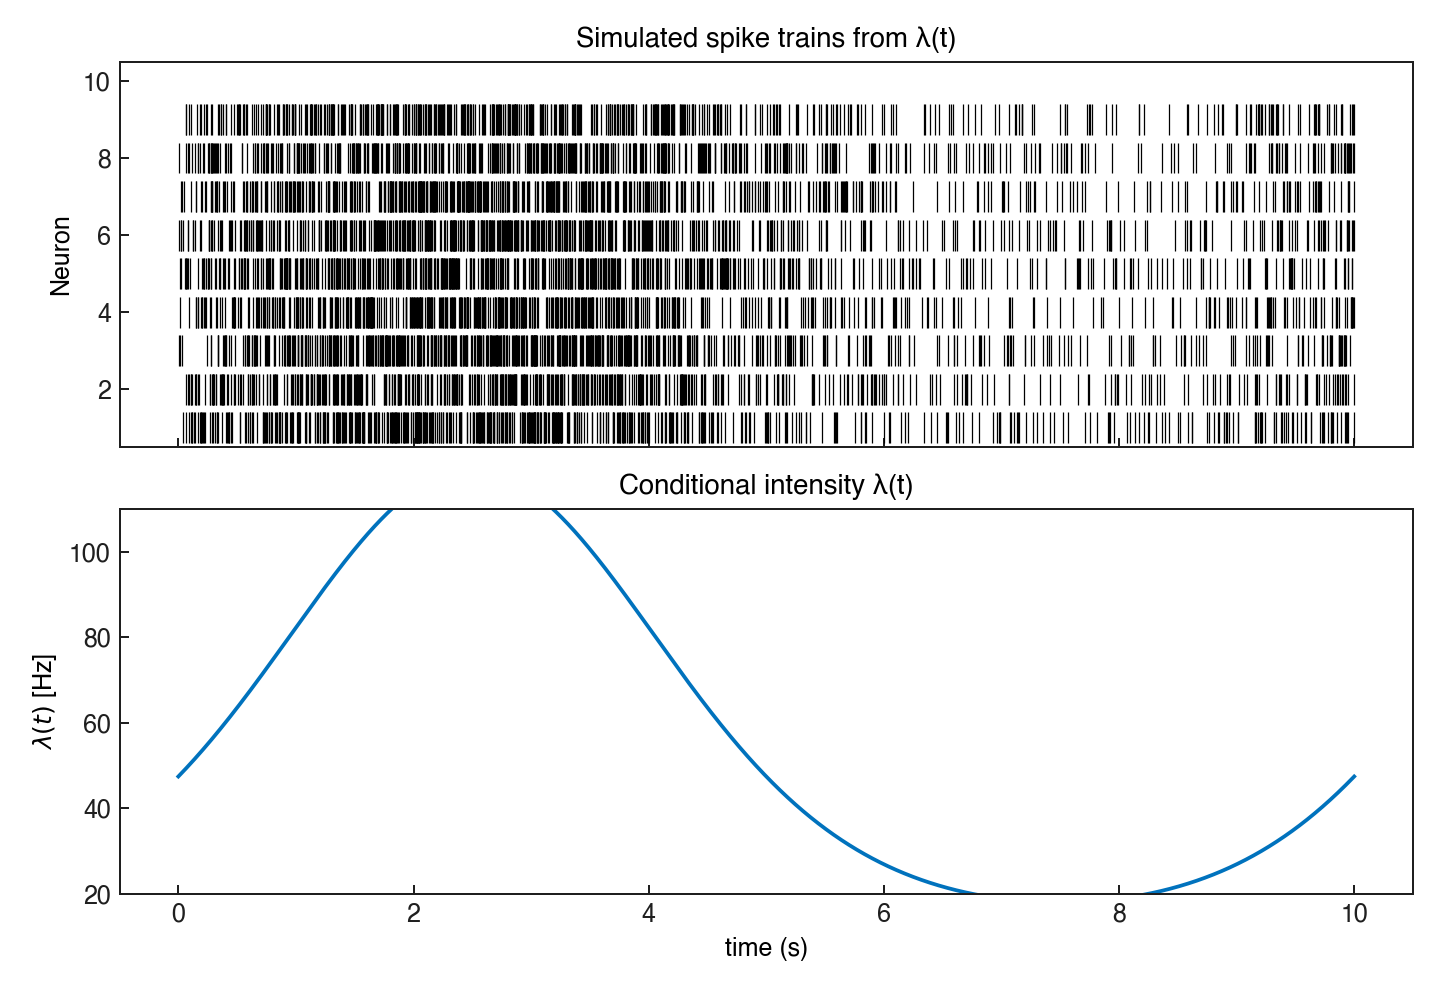

In [1]:
# nSTAT-python notebook example: DecodingExample
from pathlib import Path
import sys

REPO_ROOT = Path.cwd().resolve().parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))
SRC_PATH = (REPO_ROOT / "src").resolve()
if str(SRC_PATH) not in sys.path:
    sys.path.insert(0, str(SRC_PATH))

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import numpy as np

from nstat import Analysis, CIF, ConfigColl, CovColl, Covariate, DecodingAlgorithms, Trial, TrialConfig
from nstat.notebook_figures import FigureTracker

np.random.seed(0)
OUTPUT_ROOT = REPO_ROOT / "output" / "notebook_images"
__tracker = FigureTracker(topic="DecodingExample", output_root=OUTPUT_ROOT, expected_count=7)


def _prepare_figure(matlab_line: str, *, figsize=(8.0, 4.5)):
    fig = __tracker.new_figure(matlab_line)
    fig.clear()
    fig.set_size_inches(*figsize)
    return fig


def _plot_raster(ax, spike_coll):
    for row in range(spike_coll.numSpikeTrains):
        train = spike_coll.getNST(row)
        spikes = np.asarray(train.getSpikeTimes(), dtype=float).reshape(-1)
        if spikes.size:
            ax.vlines(spikes, row - 0.4, row + 0.4, color="k", linewidth=0.5)
    ax.set_ylabel("Neuron")
    ax.set_ylim(0.5, spike_coll.numSpikeTrains + 0.5)


def _plot_decoded_ci(ax, time, decoded, cov, stim, title):
    center = np.asarray(decoded, dtype=float).reshape(-1)
    variance = np.asarray(cov, dtype=float).reshape(-1)
    sigma = np.sqrt(np.maximum(variance, 0.0))
    z_val = 3.0
    lower = center - z_val * sigma
    upper = center + z_val * sigma
    # MATLAB-style lime-green CI bands to match DecodingExample reference figure
    band_color = "#00FF00"
    ax.plot(time[: center.size], center, "b", linewidth=1.5, label=r"$x_{k|k}(t)$")
    ax.plot(time[: center.size], lower, color=band_color, linewidth=1.0, label=r"$x_{k|k}(t)-3\sigma_{kk}$")
    ax.plot(time[: center.size], upper, color=band_color, linewidth=1.0, label=r"$x_{k|k}(t)+3\sigma_{kk}$")
    ax.plot(time[: center.size], np.asarray(stim).reshape(-1)[: center.size], "k", linewidth=1.5, label=r"$x(t)$")
    ax.set_title(title)
    ax.set_xlabel("time (s)")
    ax.legend(loc="upper right", frameon=False, fontsize=8)


# SECTION 0: STIMULUS DECODING
# In this example we decode a univariate stimulus from simulated point-process observations by following the MATLAB DecodingExample workflow.


Text(0, 0.5, 'Hz')

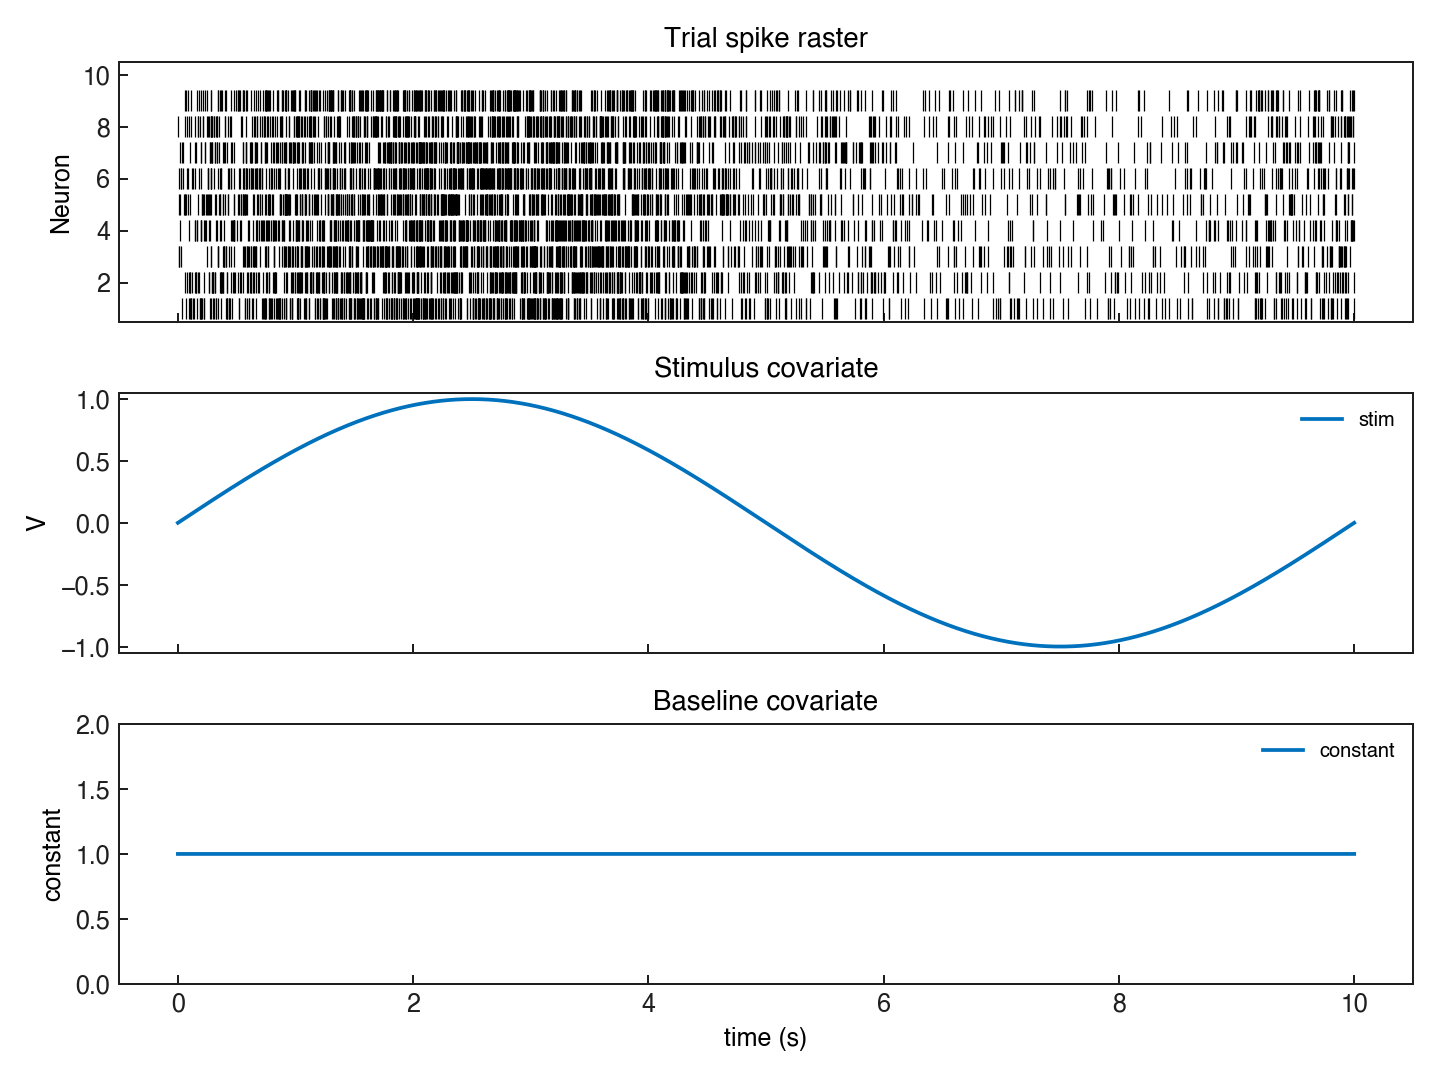

In [2]:
# SECTION 1: Generate the conditional Intensity Function
plt.close("all")
delta = 0.001
Tmax = 10.0
time = np.arange(0.0, Tmax + delta, delta)
f = 0.1
b1 = 1.0
b0 = -3.0
x = np.sin(2.0 * np.pi * f * time)
exp_data = np.exp(b1 * x + b0)
lambda_data = exp_data / (1.0 + exp_data)
lambda_cov = Covariate(time, lambda_data / delta, "\\Lambda(t)", "time", "s", "Hz", ["lambda_1"])

numRealizations = 10
spikeColl = CIF.simulateCIFByThinningFromLambda(lambda_cov, numRealizations=numRealizations)

fig = _prepare_figure("figure", figsize=(8.0, 5.5))
axs = fig.subplots(2, 1, sharex=True)
_plot_raster(axs[0], spikeColl)
axs[0].set_title("Simulated spike trains from λ(t)")
axs[1].plot(time, lambda_cov.data[:, 0], color="C0", linewidth=1.5)
axs[1].set_title("Conditional intensity λ(t)")
axs[1].set_xlabel("time (s)")
axs[1].set_ylabel(r"$\lambda(t)$ [Hz]")
axs[1].set_ylim(20, 110)


<Figure size 1300x750 with 5 Axes>

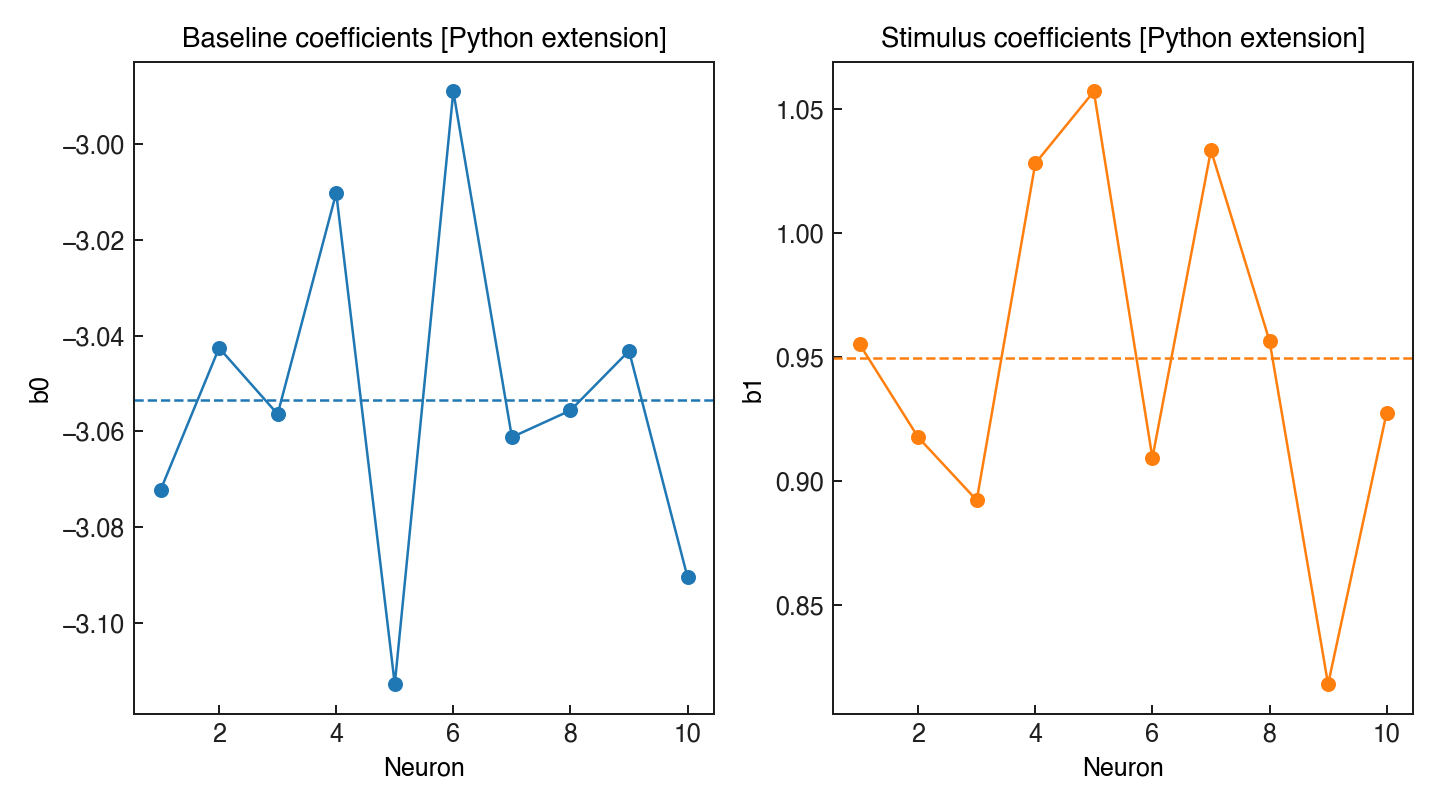

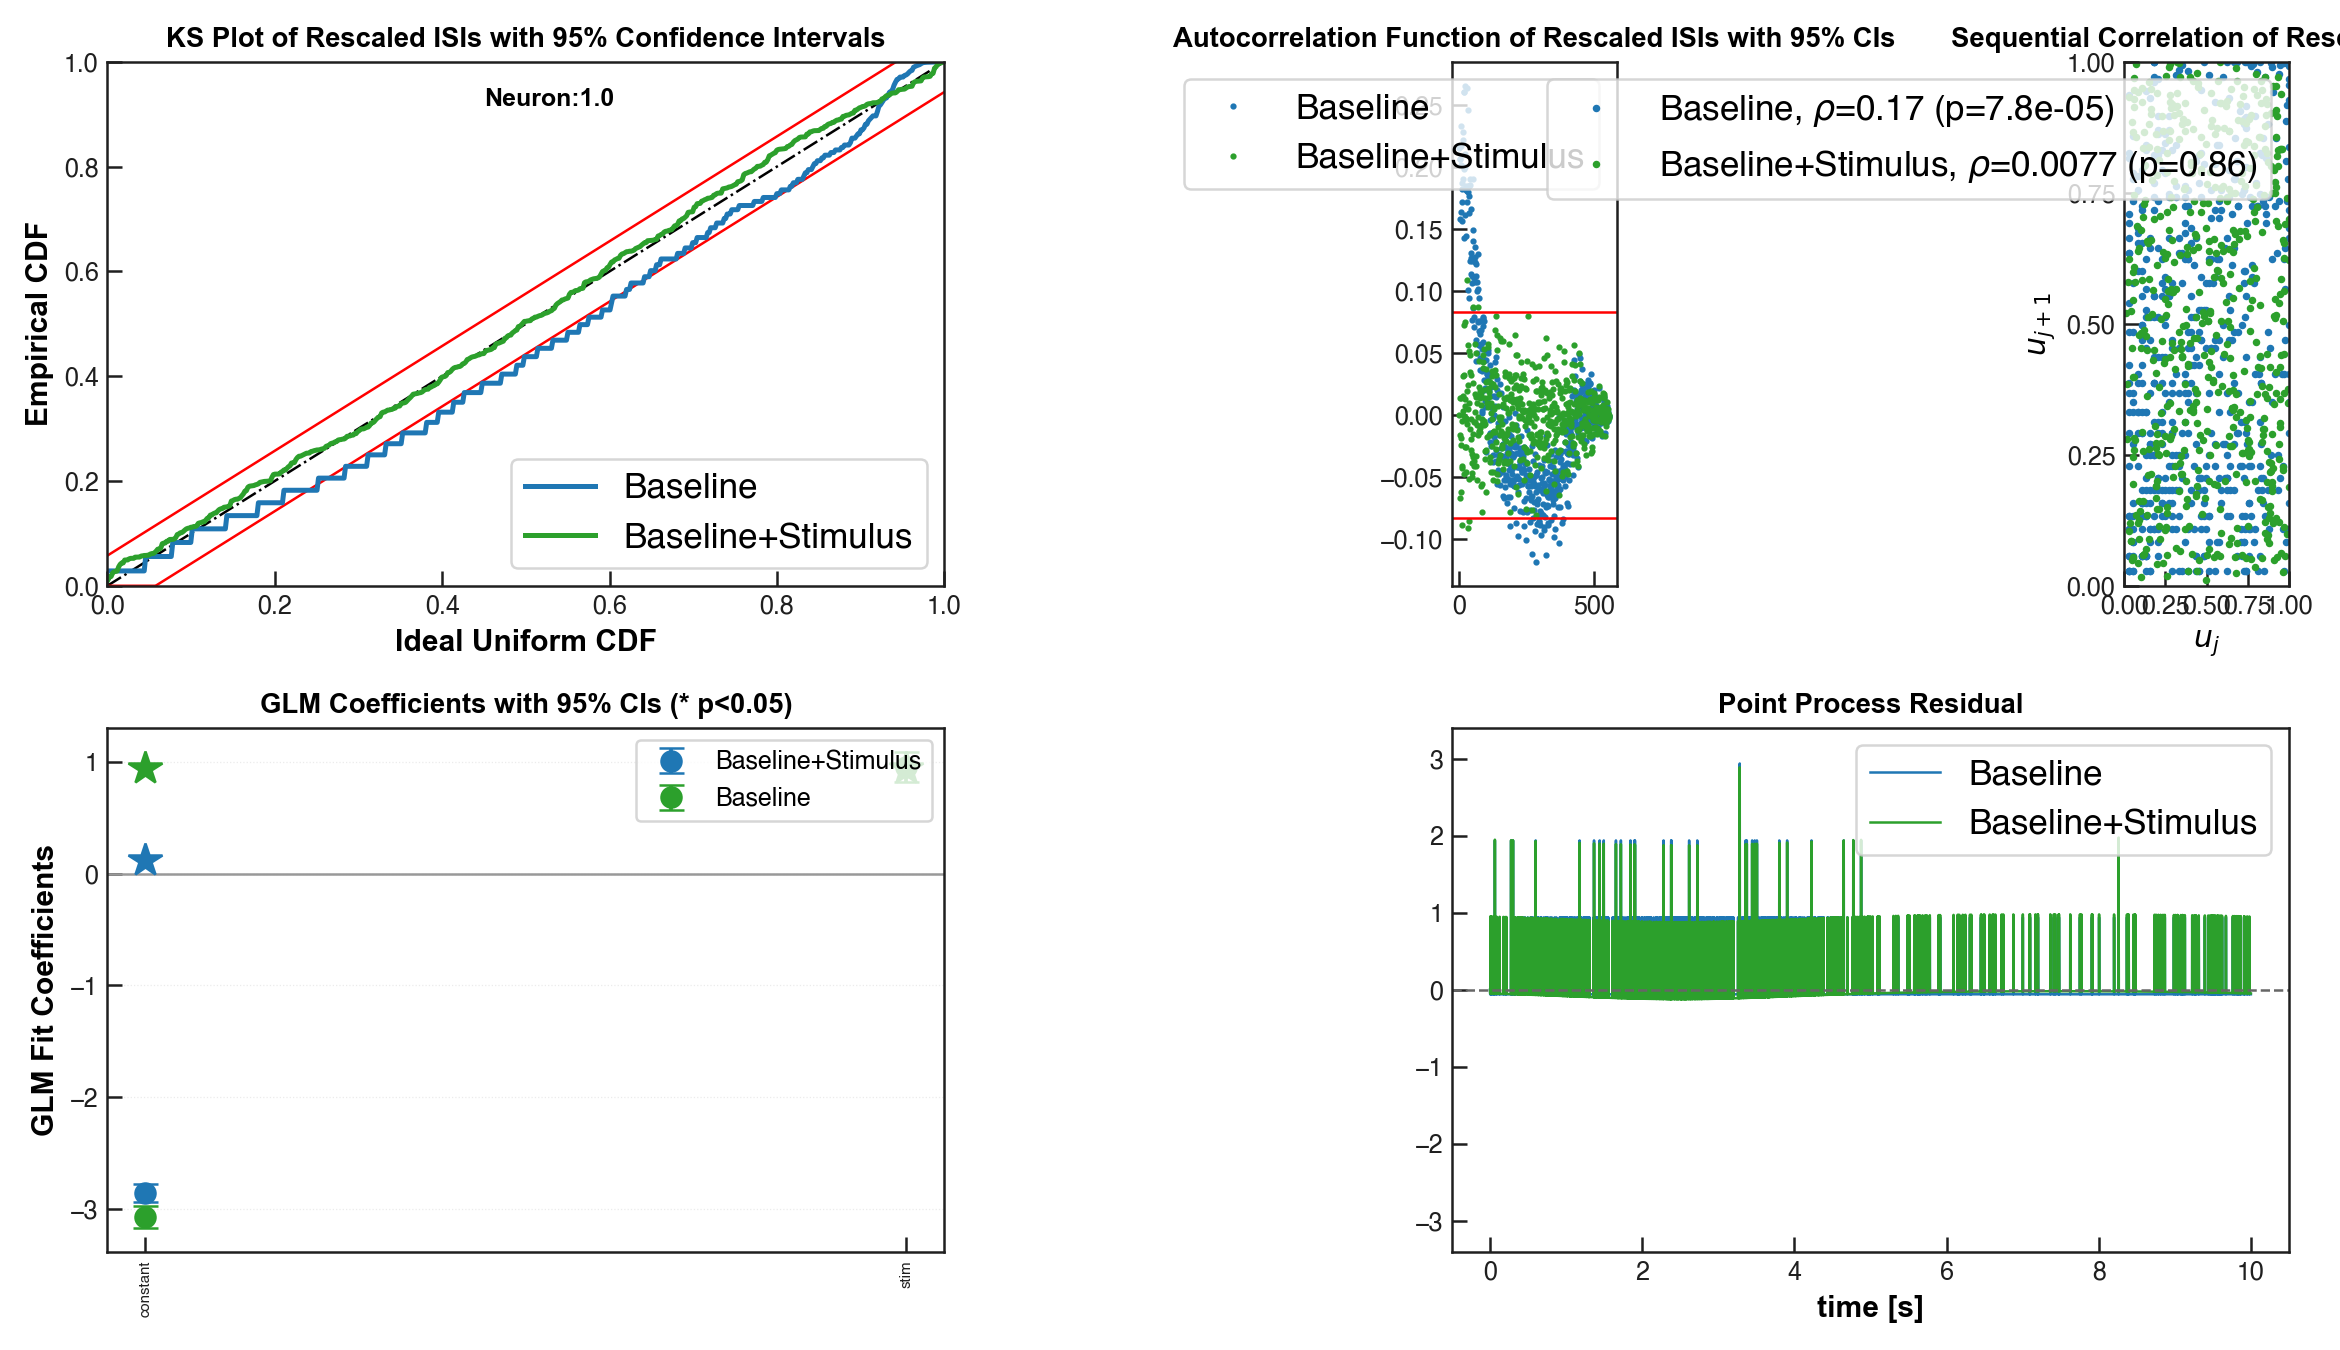

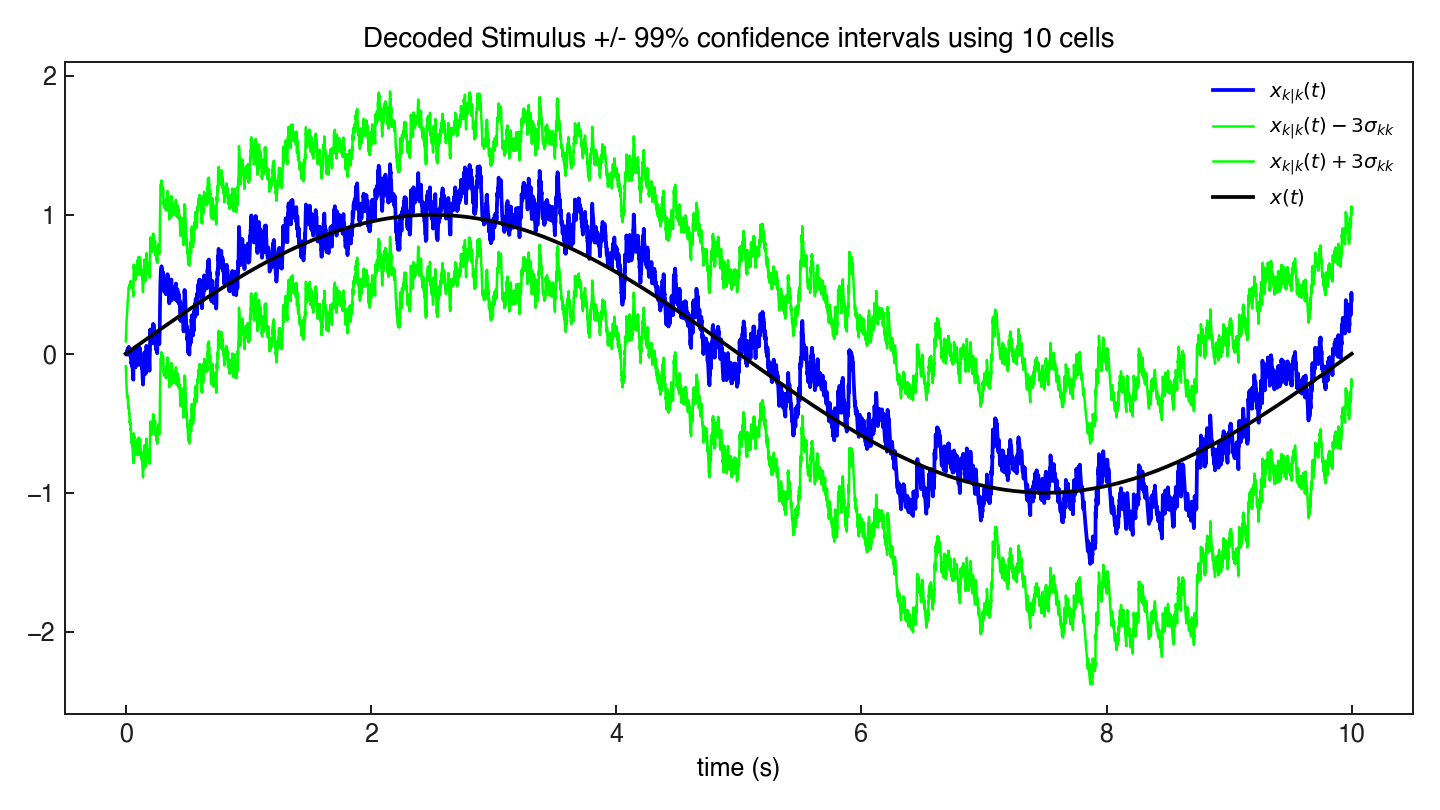

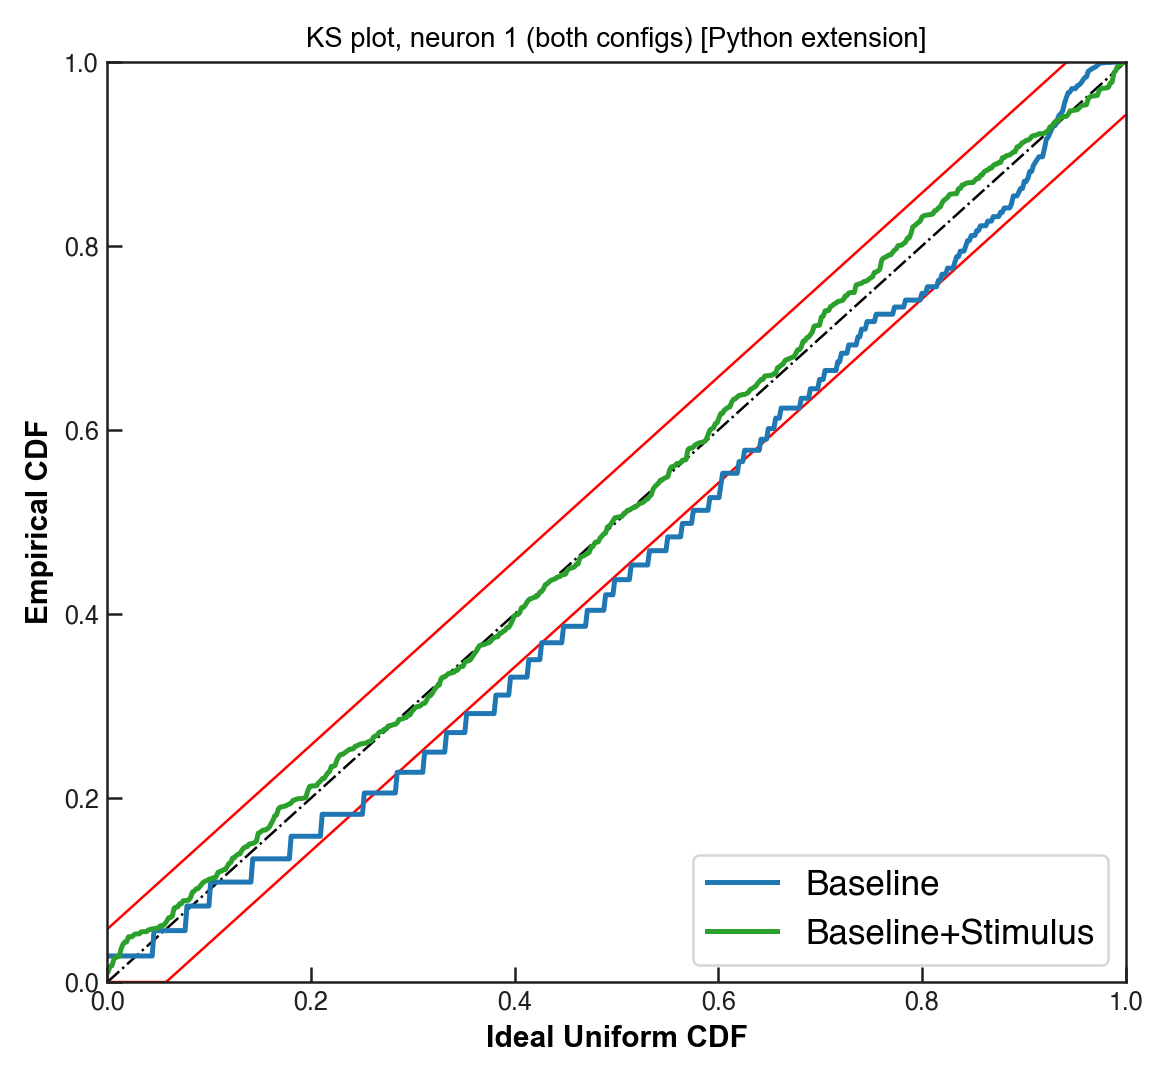

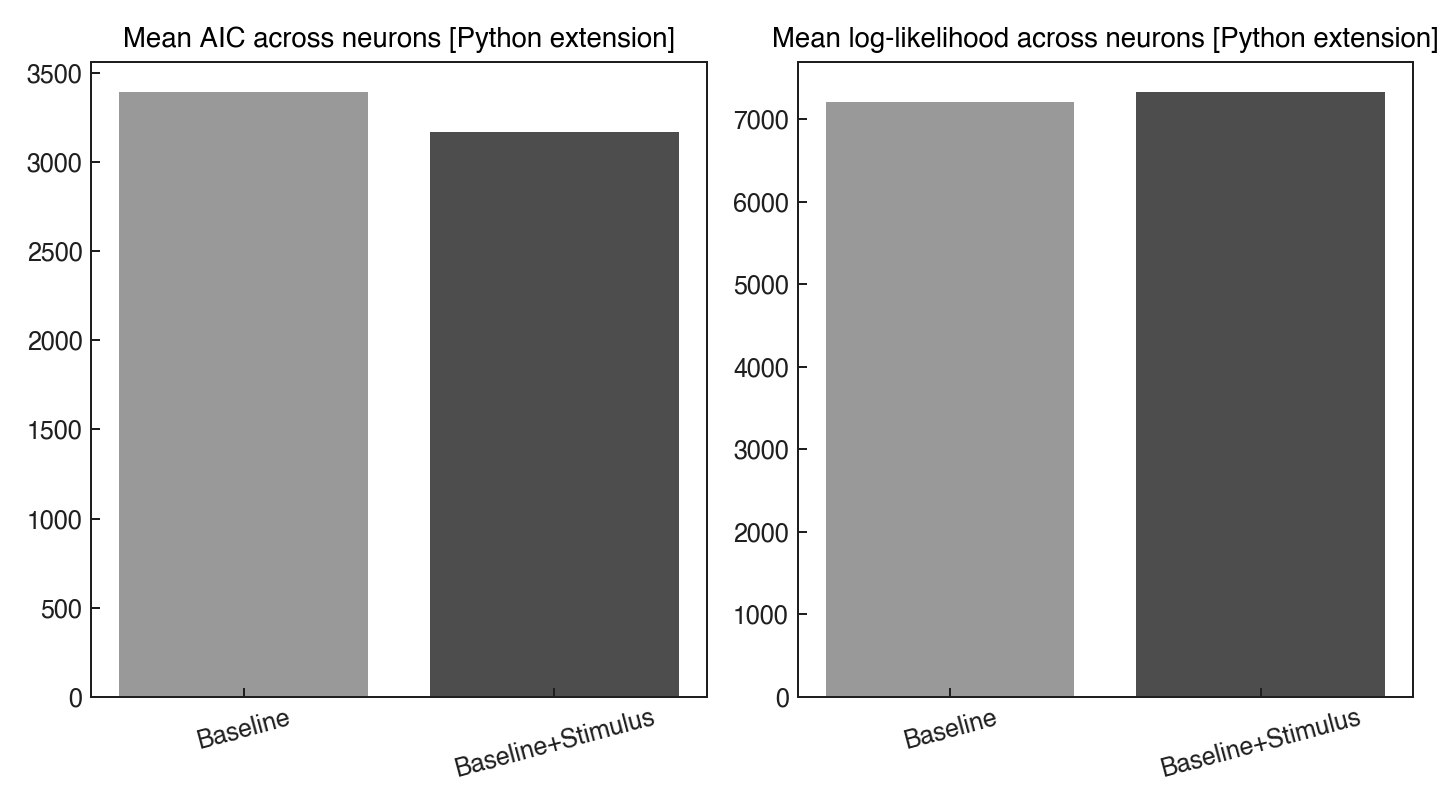

In [3]:
# SECTION 2: Fit a model to the spikedata to obtain a model CIF
stim = Covariate(time, x, "Stimulus", "time", "s", "V", ["stim"])
baseline = Covariate(time, np.ones_like(time), "Baseline", "time", "s", "", ["constant"])
cc = CovColl([stim, baseline])
trial = Trial(spikeColl, cc)

fig = _prepare_figure("figure", figsize=(8.0, 6.0))
axs = fig.subplots(3, 1, sharex=True)
_plot_raster(axs[0], spikeColl)
axs[0].set_title("Trial spike raster")
axs[1].plot(time, stim.data[:, 0], color="C0", linewidth=1.5, label="stim")
axs[1].set_title("Stimulus covariate")
axs[1].set_ylabel("V")
axs[1].set_ylim(-1.05, 1.05)
axs[1].legend(loc="upper right", frameon=False, fontsize=8)
axs[2].plot(time, baseline.data[:, 0], color="C0", linewidth=1.5, label="constant")
axs[2].set_title("Baseline covariate")
axs[2].set_ylabel("constant")
axs[2].set_xlabel("time (s)")
axs[2].set_ylim(0, 2)
axs[2].legend(loc="upper right", frameon=False, fontsize=8)

cfgColl = ConfigColl(
    [
        TrialConfig([["Baseline", "constant"]], 1000.0, [], [], name="Baseline"),
        TrialConfig([["Baseline", "constant"], ["Stimulus", "stim"]], 1000.0, [], [], name="Baseline+Stimulus"),
    ]
)
results = Analysis.RunAnalysisForAllNeurons(trial, cfgColl, 0)

# Extract coefficients by label so the order doesn't depend on the
# underlying CovColl iteration order.  ``getCoeffs(1)`` returns
# coefficients in the design-matrix column order, which follows CovColl
# (here: stim, constant) rather than the TrialConfig spec order
# (Baseline first).  Without label-based lookup, b0/b1 get swapped and
# the decoder produces nonsense.
def _coeff_by_label(fit, label, config_idx=1):
    coeffs, labels, _ = fit.getCoeffsWithLabels(config_idx)
    idx = labels.index(label)
    return float(coeffs[idx])

b0_vec = np.array([_coeff_by_label(fit, "constant") for fit in results])
b1_vec = np.array([_coeff_by_label(fit, "stim") for fit in results])
paramEst = np.vstack([b0_vec, b1_vec])  # row 0 = b0 (intercept), row 1 = b1 (stim)
meanParams = np.mean(paramEst, axis=1)
aic_matrix = np.vstack([fit.AIC for fit in results])
logll_matrix = np.vstack([fit.logLL for fit in results])
config_names = results[0].configNames

# fig_003 (Python extension): per-neuron MLE coefficients across the 10 cells.
# Marked as extension in parity/notebook_fidelity.yml since MATLAB DecodingExample
# does not render a per-neuron coefficient figure.
fig = _prepare_figure("figure", figsize=(8.0, 4.5))
axs = fig.subplots(1, 2)
neuron_idx = np.arange(1, paramEst.shape[1] + 1)
axs[0].plot(neuron_idx, paramEst[0], "o-", color="tab:blue", label="b0")
axs[0].axhline(meanParams[0], color="tab:blue", linestyle="--", linewidth=1.0)
axs[0].set_title("Baseline coefficients [Python extension]")
axs[0].set_xlabel("Neuron")
axs[0].set_ylabel("b0")
axs[1].plot(neuron_idx, paramEst[1], "o-", color="tab:orange", label="b1")
axs[1].axhline(meanParams[1], color="tab:orange", linestyle="--", linewidth=1.0)
axs[1].set_title("Stimulus coefficients [Python extension]")
axs[1].set_xlabel("Neuron")
axs[1].set_ylabel("b1")

# fig_004: per-neuron diagnostic panel (mirrors MATLAB results{1}.plotResults).
# Reordered to fig_004 so the MATLAB KS/ACF/sequential-correlation/residual panel
# aligns with MATLAB's figure ordering in the gallery composite.
from nstat import Analysis as _Analysis
fig = _prepare_figure("results{1}.plotResults", figsize=(13.0, 7.5))
results[0].plotResults(handle=fig)

# fig_005: decoded stimulus with 99% confidence intervals — matches MATLAB
# DecodingExample's primary decoded-stimulus figure.
b0_est = paramEst[0, :]
b1_est = paramEst[1, :]
lambdaCIF = [CIF([b0_est[i], b1_est[i]], ["1", "x"], ["x"], "binomial") for i in range(numRealizations)]

spikeColl.resample(1.0 / delta)
dN = spikeColl.dataToMatrix()
Q = 2.0 * np.std(np.diff(stim.data[:, 0]))
A = 1.0
x_p, W_p, x_u, W_u, *_ = DecodingAlgorithms.PPDecodeFilterLinear(A, Q, dN.T, b0_est, b1_est, "binomial", delta)

fig = _prepare_figure("figure", figsize=(8.0, 4.5))
ax = fig.subplots(1, 1)
_plot_decoded_ci(
    ax, time, x_u, W_u, stim.data[:, 0],
    f"Decoded Stimulus +/- 99% confidence intervals using {numRealizations} cells",
)

# fig_006 (Python extension): KS plot for neuron 1 comparing both fits.
fig = _prepare_figure("Analysis.KSPlot(results)", figsize=(6.5, 6.0))
ax = fig.subplots(1, 1)
results[0].KSPlot(fit_num=None, handle=ax)
ax.set_title("KS plot, neuron 1 (both configs) [Python extension]")

# fig_007 (Python extension): mean AIC / log-likelihood across neurons.
fig = _prepare_figure("figure", figsize=(8.0, 4.5))
axs = fig.subplots(1, 2)
xloc = np.arange(len(config_names))
axs[0].bar(xloc, np.mean(aic_matrix, axis=0), color=["0.6", "0.3"])
axs[0].set_xticks(xloc, config_names, rotation=15)
axs[0].set_title("Mean AIC across neurons [Python extension]")
axs[1].bar(xloc, np.mean(logll_matrix, axis=0), color=["0.6", "0.3"])
axs[1].set_xticks(xloc, config_names, rotation=15)
axs[1].set_title("Mean log-likelihood across neurons [Python extension]")

# Finalize the figure tracker to write all PNGs to the output directory.
__tracker.finalize()
